(11761, 51)
       BEGIN_DATE_TIME      STATE  MAGNITUDE DAMAGE_PROPERTY
17  24-OCT-23 08:59:00  WISCONSIN       1.00           0.00K
18  24-OCT-23 09:36:00  WISCONSIN       0.88           0.00K
22  24-OCT-23 09:07:00  WISCONSIN       1.75           0.00K
24  24-OCT-23 08:33:00  WISCONSIN       2.25           0.00K
25  06-AUG-23 20:47:00   ILLINOIS       1.25           0.00K
26  24-OCT-23 08:30:00  WISCONSIN       1.00           0.00K
30  06-AUG-23 20:49:00   ILLINOIS       1.00           0.00K
31  24-OCT-23 09:06:00  WISCONSIN       1.25           0.00K
35  06-AUG-23 18:20:00   ILLINOIS       1.00           0.00K
36  06-AUG-23 18:26:00   ILLINOIS       1.75           0.00K
Il y a 4968 évènements avec dégâts, soit 42.2 % du total grêle.


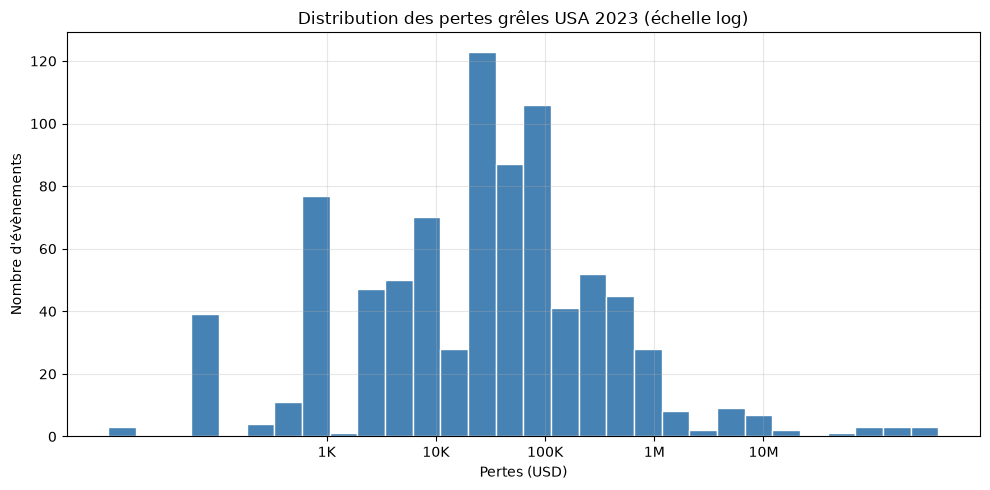

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#après r ' '
#dataset 2023 téléchargé depuis ncei.noaa.gov
chemin = r'C:\Users\jhmag\Downloads\StormEvents_details-ftp_v1.0_d2023_c20260323.csv.gz'
# pd.read_csv, compression, low_memory
df_raw = pd.read_csv(chemin, compression = 'gzip', low_memory = False)
#que les lignes qui concernent la grêle
df_hail = df_raw[df_raw['EVENT_TYPE'] == 'Hail']
#pour afficher le nombre de lignes et colonnes
print(df_hail.shape)
print(df_hail[['BEGIN_DATE_TIME', 'STATE', 'MAGNITUDE', 'DAMAGE_PROPERTY']].head(10))
#!= différent de
df_hail_damage = df_hail[df_hail['DAMAGE_PROPERTY'] != '0.00K']
#.shape[0] pour le nombre de lignes, f"texte{}"
print(f"Il y a {df_hail_damage.shape[0]} évènements avec dégâts, soit {round(df_hail_damage.shape[0]/df_hail.shape[0]*100,1)} % du total grêle.")
#fct pd.isna
def convertir_damage(valeur):
    if pd.isna(valeur):
        return 0
        
    valeur=str(valeur).strip()
#elif fait qu'a la première condition vrai, la fonction exécute son return sinon elle teste chaque condition
    if valeur.endswith('K'):
        return float(valeur[:-1])*1_000

    elif valeur.endswith('M'):
        return float(valeur[:-1])*1_000_000

    elif valeur.endswith('B'):
        return float(valeur[:-1])*1_000_000_000

    else:
        return float(valeur) if valeur else 0
        
df_hail_damage = df_hail_damage.copy()
#ajoute une colonne dmg usd a partir de dmg property et la fonction appliquée
df_hail_damage['DAMAGE_USD'] = df_hail_damage['DAMAGE_PROPERTY'].apply(convertir_damage)

df_hail_final = df_hail_damage[df_hail_damage['DAMAGE_USD'] > 0]

plt.figure(figsize=(10,5))
plt.hist(np.log10(df_hail_final['DAMAGE_USD']), bins=30, color='steelblue', edgecolor='white')

plt.xticks([3,4,5,6,7],['1K','10K','100K','1M','10M'])

    
plt.title('Distribution des pertes grêles USA 2023 (échelle log)')

plt.xlabel('Pertes (USD)')

plt.ylabel("Nombre d'évènements")

plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()


In [3]:
# Statistiques descriptives sur les pertes réelles
print(df_hail_final['DAMAGE_USD'].describe())

count    8.500000e+02
mean     2.590332e+06
std      2.398298e+07
min      1.000000e+01
25%      5.000000e+03
50%      3.000000e+04
75%      1.000000e+05
max      4.000000e+08
Name: DAMAGE_USD, dtype: float64


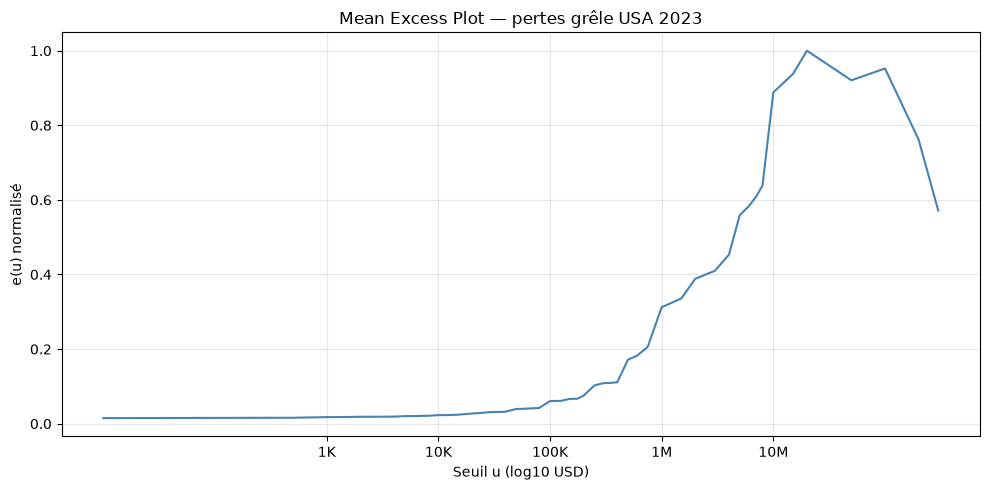

In [6]:
# e(u) = moyenne des excès au-dessus du seuil u). 
    
# on trie les données de manière croissante

data_sorted = np.sort(df_hail_final['DAMAGE_USD'].values)

# Pour chaque valeur u, on calcule e(u) = moyenne des excès au-dessus de u
seuils = data_sorted[:-1]  # tous les points sauf le dernier comme seuils car rien au dessus
mean_excess = [np.mean(data_sorted[data_sorted > u] - u) for u in seuils]

plt.figure(figsize=(10, 5))
plt.plot(np.log10(seuils), mean_excess / np.max(mean_excess), 
         color='steelblue', linewidth=1.5)
plt.title('Mean Excess Plot — pertes grêle USA 2023')
plt.xlabel('Seuil u (log10 USD)')
plt.ylabel('e(u) normalisé')
plt.xticks([3, 4, 5, 6, 7], ['1K', '10K', '100K', '1M', '10M'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# scipy = Scientific Python — librairie de calculs statistiques avancés
# stats = le module de scipy dédié aux distributions de probabilité
# from X import Y = on importe SEULEMENT le sous-module "stats" de scipy
# différent de "import scipy as sp" qui chargerait TOUT scipy (énorme, inutile)
# on n'a besoin que de "stats", donc on cible précisément ce module
from scipy import stats

# stats.lognorm.fit() trouve les paramètres de la loi lognormale
# qui correspondent le mieux à nos 850 valeurs de pertes
# "fit" = ajuster une courbe théorique sur des données réelles

# Une loi lognormale a 3 paramètres techniques :
# - shape (souvent noté sigma) = contrôle la dispersion/largeur de la courbe
# - loc = décale la distribution sur l'axe (translation)
# - scale = lié à la moyenne (exp(mu)), contrôle l'échelle

# floc=0 = on FIXE loc à 0 (on ne le laisse pas varier)
# Pourquoi ? Parce que des pertes ne peuvent pas être négatives —
# on force la distribution à commencer à 0, pas avant
#Cette fonction prend tes 850 vraies valeurs et cherche : "quelles valeurs de shape et scale font que la courbe lognormale correspondante ressemble le plus possible à ces 850 points ?"
shape, loc, scale = stats.lognorm.fit(df_hail_final['DAMAGE_USD'], floc=0)

# :.3f = formate le nombre avec 3 décimales après la virgule
# f"texte {variable:.3f}" = f-string avec formatage de précision
print(f"Shape (sigma) : {shape:.3f}")

# :.0f = formate sans décimale (nombre entier)
print(f"Scale (exp(mu)) : {scale:.0f}")

#résultat: 
#Shape (sigma) = 2.637 — c'est élevé. Plus sigma est grand, plus la distribution est étalée/asymétrique. Pour comparaison, une lognormale "normale" a souvent sigma entre 0.5 et 1.5. Un sigma de 2.6 confirme une queue très épaisse — cohérent avec ton ratio moyenne/médiane de 86x.
#Scale (exp(mu)) = 25995 — proche de ta médiane (30000), c'est cohérent : pour une lognormale, scale représente la médiane théorique de la distribution.

Shape (sigma) : 2.637
Scale (exp(mu)) : 25995


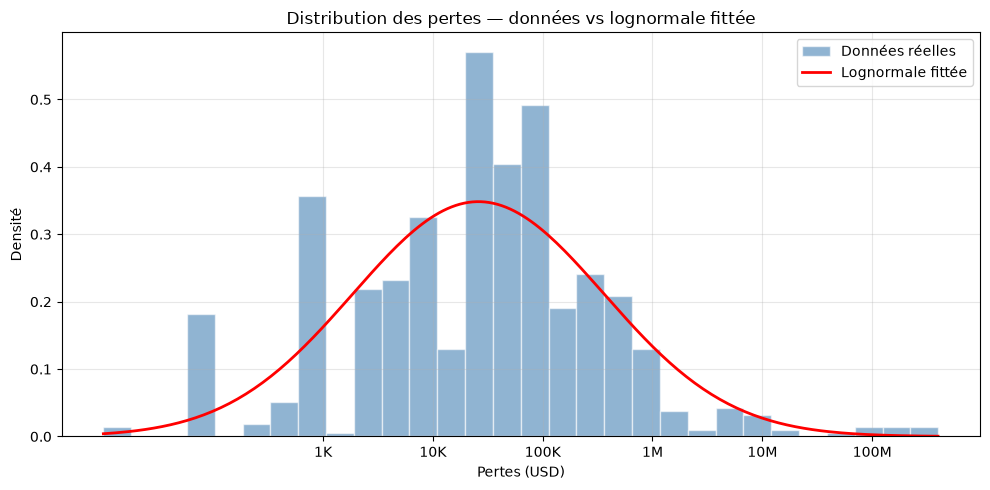

In [8]:
# génère 200 valeurs entre 10^1 (le min) et 10^8.6 (le max)
# soit entre 10 et ~400 000 000
# On crée une plage de valeurs de pertes de 10 à 400M, en échelle log
x = np.logspace(1, 8.6, 200)

# stats.lognorm.pdf() calcule la densité de probabilité théorique
# pour chaque valeur de x, selon notre lognormale fittée
#
y = stats.lognorm.pdf(x, shape, loc=0, scale=scale)

plt.figure(figsize=(10, 5))

# Histogramme des vraies données (normalisé en densité avec density=True)
# density=True transforme l'axe Y en densité de probabilité 
# au lieu de comptage brut — nécessaire pour comparer avec la courbe
plt.hist(np.log10(df_hail_final['DAMAGE_USD']), bins=30, density=True, 
         color='steelblue', edgecolor='white', alpha=0.6, label='Données réelles')

# On trace la courbe théorique — np.log10(x) pour rester sur la même échelle
plt.plot(np.log10(x), y * x * np.log(10), color='red', linewidth=2, label='Lognormale fittée')

plt.xticks([3, 4, 5, 6, 7, 8], ['1K', '10K', '100K', '1M', '10M', '100M'])
plt.title('Distribution des pertes — données vs lognormale fittée')
plt.xlabel('Pertes (USD)')
plt.ylabel('Densité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# .ppf() = inverse de la fonction de répartition cumulée
# on lui donne une probabilité (0.99), elle renvoie la valeur de perte correspondante
#VaR 99% = "le montant de perte qui n'est dépassé que 1% du temps". Si tu te projettes sur 100 événements futurs, 99 seront sous ce seuil, 1 le dépassera.
var_99 = stats.lognorm.ppf(0.99, shape, loc=0, scale=scale)

print(f"VaR 99% : {var_99:,.0f} USD")

# Pour comparaison, calculons aussi la VaR 95% et la VaR 99.5%
var_95 = stats.lognorm.ppf(0.95, shape, loc=0, scale=scale)
var_995 = stats.lognorm.ppf(0.995, shape, loc=0, scale=scale)

print(f"VaR 95%   : {var_95:,.0f} USD")
print(f"VaR 99.5% : {var_995:,.0f} USD")

VaR 99% : 11,984,212 USD
VaR 95%   : 1,987,382 USD
VaR 99.5% : 23,135,132 USD


In [10]:
from scipy import stats

# Avec une seule année, notre meilleure estimation de lambda 
# est simplement le nombre d'événements observés
lambda_estime = df_hail_final.shape[0]

print(f"Lambda (fréquence annuelle estimée) : {lambda_estime}")

# La Poisson nous dit aussi : quelle est la probabilité d'avoir 
# exactement 900 événements l'année prochaine ?
proba_900 = stats.poisson.pmf(900, lambda_estime)
print(f"Probabilité d'avoir exactement 900 événements : {proba_900:.4f}")

Lambda (fréquence annuelle estimée) : 850
Probabilité d'avoir exactement 900 événements : 0.0031


In [17]:
# La prime pure = fréquence x sévérité moyenne
# C'est le montant moyen que l'assureur s'attend à payer par an

# Pour une lognormale, la moyenne théorique se calcule ainsi :
# moyenne = scale * exp(shape² / 2)

severite_moyenne = scale * np.exp(shape**2 / 2)
print(f"Sévérité moyenne (théorique) : {severite_moyenne:,.0f} USD")

prime_pure = lambda_estime * severite_moyenne
print(f"Prime pure annuelle : {prime_pure:,.0f} USD")

# Comparaison avec la moyenne empirique (directement sur les données)
print(f"Moyenne empirique observée : {df_hail_final['DAMAGE_USD'].mean():,.0f} USD")

Sévérité moyenne (théorique) : 840,083 USD
Prime pure annuelle : 714,070,678 USD
Moyenne empirique observée : 2,590,332 USD


In [16]:
# Fit d'une Pareto généralisée sur les mêmes données
shape_pareto, loc_pareto, scale_pareto = stats.genpareto.fit(df_hail_final['DAMAGE_USD'], floc=0)

print(f"Shape Pareto : {shape_pareto:.3f}")
print(f"Scale Pareto : {scale_pareto:,.0f}")

# Moyenne théorique de la Pareto généralisée
# Attention : si shape >= 1, la moyenne est infinie (queue trop épaisse)
if shape_pareto < 1:
    moyenne_pareto = scale_pareto / (1 - shape_pareto)
    print(f"Moyenne théorique Pareto : {moyenne_pareto:,.0f} USD")
else:
    print("Moyenne théorique Pareto : infinie (shape >= 1)")

# VaR 99% selon Pareto, pour comparer avec la lognormale (11.98M)
var_99_pareto = stats.genpareto.ppf(0.99, shape_pareto, loc=0, scale=scale_pareto)
print(f"VaR 99% Pareto : {var_99_pareto:,.0f} USD")

Shape Pareto : 1.982
Scale Pareto : 14,845
Moyenne théorique Pareto : infinie (shape >= 1)
VaR 99% Pareto : 69,044,738 USD


In [13]:
# Impossible de calculer une prime pure stable
# La moyenne théorique diverge — pas de formule fermée utilisable
#prime_pure_pareto = "indéfinie (shape ≥ 1)"

In [22]:
# Fit Weibull (version "exponentielle" généralisée, weibull_min en scipy)
shape_weib, loc_weib, scale_weib = stats.weibull_min.fit(df_hail_final['DAMAGE_USD'], floc=0)

print(f"Shape Weibull : {shape_weib:.3f}")
print(f"Scale Weibull : {scale_weib:,.0f}")

# VaR 99% Weibull
var_99_weib = stats.weibull_min.ppf(0.99, shape_weib, loc=0, scale=scale_weib)
print(f"VaR 99% Weibull : {var_99_weib:,.0f} USD")

from scipy.special import gamma

# Moyenne théorique Weibull = scale × Γ(1 + 1/k)
# Γ = fonction gamma — généralisation de la factorielle aux réels
moyenne_weib = scale_weib * gamma(1 + 1/shape_weib)
prime_pure_weib = lambda_estime * moyenne_weib
print(f"Sévérité moyenne Weibull : {moyenne_weib:,.0f} USD")
print(f"Prime pure Weibull : {prime_pure_weib:,.0f} USD")

Shape Weibull : 0.345
Scale Weibull : 98,368
VaR 99% Weibull : 8,179,841 USD
Sévérité moyenne Weibull : 517,900 USD
Prime pure Weibull : 440,215,405 USD


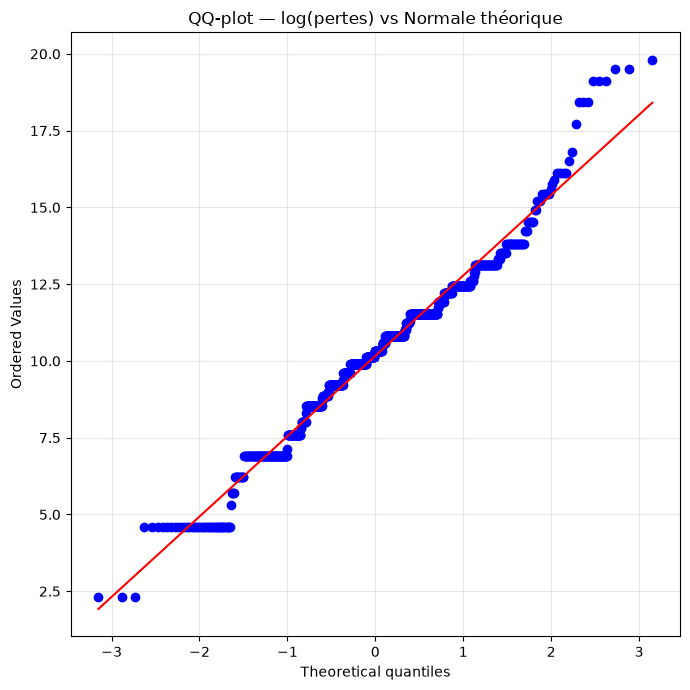

In [23]:
# QQ-plot : compare les quantiles empiriques vs théoriques lognormaux
fig, ax = plt.subplots(figsize=(7, 7))

# génère les quantiles théoriques de notre lognormale fittée
stats.probplot(np.log(df_hail_final['DAMAGE_USD']), 
               dist='norm', 
               plot=ax)

ax.set_title('QQ-plot — log(pertes) vs Normale théorique')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# --- Comparaison AIC ---
# AIC = 2*k - 2*log-vraisemblance
# k = nombre de paramètres (2 pour chacune de nos 3 lois)
# Plus l'AIC est BAS, meilleur est le fit

k = 2  # shape + scale pour les 3 lois (loc fixé à 0)

loglik_lognorm = np.sum(stats.lognorm.logpdf(df_hail_final['DAMAGE_USD'], shape, loc=0, scale=scale))
loglik_pareto = np.sum(stats.genpareto.logpdf(df_hail_final['DAMAGE_USD'], shape_pareto, loc=0, scale=scale_pareto))
loglik_weib = np.sum(stats.weibull_min.logpdf(df_hail_final['DAMAGE_USD'], shape_weib, loc=0, scale=scale_weib))

aic_lognorm = 2*k - 2*loglik_lognorm
aic_pareto = 2*k - 2*loglik_pareto
aic_weib = 2*k - 2*loglik_weib

print(f"\nAIC Lognormale : {aic_lognorm:,.1f}")
print(f"AIC Pareto     : {aic_pareto:,.1f}")
print(f"AIC Weibull    : {aic_weib:,.1f}")


AIC Lognormale : 21,345.9
AIC Pareto     : 21,403.3
AIC Weibull    : 21,574.1


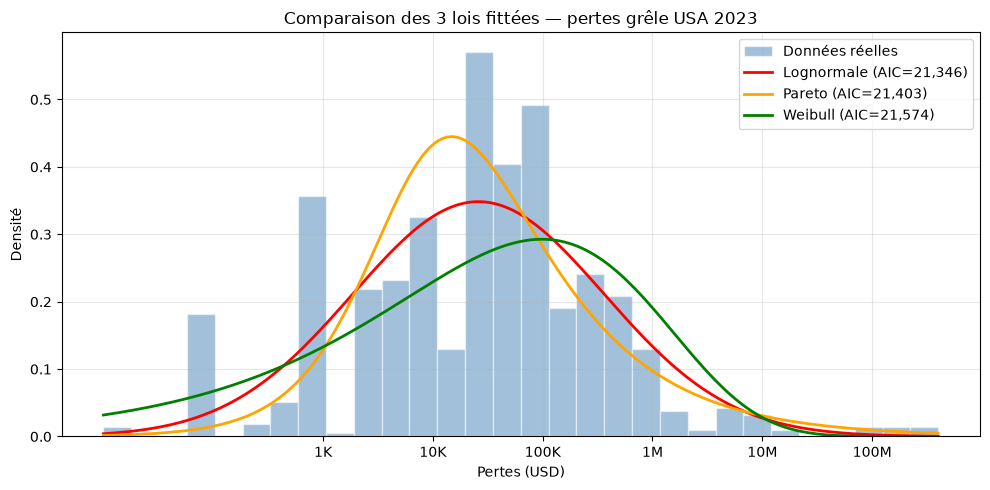

In [25]:
x = np.logspace(1, 8.6, 200)

# Densités des 3 lois (avec correction pour l'axe log)
y_lognorm = stats.lognorm.pdf(x, shape, loc=0, scale=scale) * x * np.log(10)
y_pareto = stats.genpareto.pdf(x, shape_pareto, loc=0, scale=scale_pareto) * x * np.log(10)
y_weib = stats.weibull_min.pdf(x, shape_weib, loc=0, scale=scale_weib) * x * np.log(10)

plt.figure(figsize=(10, 5))

# Histogramme données réelles
plt.hist(np.log10(df_hail_final['DAMAGE_USD']), bins=30, density=True,
         color='steelblue', edgecolor='white', alpha=0.5, label='Données réelles')

# 3 courbes fittées
plt.plot(np.log10(x), y_lognorm, color='red', linewidth=2, label=f'Lognormale (AIC={aic_lognorm:,.0f})')
plt.plot(np.log10(x), y_pareto, color='orange', linewidth=2, label=f'Pareto (AIC={aic_pareto:,.0f})')
plt.plot(np.log10(x), y_weib, color='green', linewidth=2, label=f'Weibull (AIC={aic_weib:,.0f})')

plt.xticks([3, 4, 5, 6, 7, 8], ['1K', '10K', '100K', '1M', '10M', '100M'])
plt.title('Comparaison des 3 lois fittées — pertes grêle USA 2023')
plt.xlabel('Pertes (USD)')
plt.ylabel('Densité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
 #Conclusions Niveau 2

- #Loi retenue : **Lognormale** (AIC=21,346, MEP en forme de cloche)
- #Shape σ=2.637 confirme une queue très épaisse
- #VaR 99% (lognormale) : 11.98M USD | VaR 99% (Pareto stress) : 69.04M USD
- #Fréquence annuelle estimée λ=850 (1 an de données — limite identifiée)
- #Prime pure théorique : 714M USD vs empirique 2.2Mrd USD → instabilité due à 1 an
- #QQ-plot : bon fit sur le corps, déviation en queue → Pareto recommandée pour stress test## Conclusions Niveau 2

IndentationError: unexpected indent (3620551751.py, line 1)